In [46]:
import sys
print(sys.executable)

C:\Users\gtson\PycharmProjects\CBL_17_London\.venv\Scripts\python.exe


In [47]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns
import os

print("Current working directory:")
print(os.getcwd())

DATA_DIR = Path("../../scripts/data/raw/extracted")

csv_files = list(DATA_DIR.rglob("*.csv"))

print(f"Data folder exists: {DATA_DIR.exists()}")
print(f"Total CSV files found: {len(csv_files)}")

Current working directory:
C:\Users\gtson\PycharmProjects\CBL_17_London\src\src
Data folder exists: True
Total CSV files found: 4509


In [48]:
file_inventory = []

for file in csv_files:
    parts = file.name.replace(".csv", "").split("-")
    
    # Example file:
    # 2023-04-avon-and-somerset-street.csv
    
    month = "-".join(parts[0:2])
    data_type = parts[-1]
    force = "-".join(parts[2:-1])
    
    file_inventory.append({
        "file_path": str(file),
        "file_name": file.name,
        "month": month,
        "force": force,
        "data_type": data_type,
        "file_size_mb": file.stat().st_size / (1024 * 1024)
    })

inventory_df = pd.DataFrame(file_inventory)

inventory_df.head()

,file_path,file_name,month,force,data_type,file_size_mb
0,..\..\scripts\data\raw\extracted\2023-04\2023-...,2023-04-avon-and-somerset-outcomes.csv,2023-04,avon-and-somerset,outcomes,0.62
1,..\..\scripts\data\raw\extracted\2023-04\2023-...,2023-04-avon-and-somerset-stop-and-search.csv,2023-04,avon-and-somerset-stop-and,search,0.13
2,..\..\scripts\data\raw\extracted\2023-04\2023-...,2023-04-avon-and-somerset-street.csv,2023-04,avon-and-somerset,street,3.13
3,..\..\scripts\data\raw\extracted\2023-04\2023-...,2023-04-bedfordshire-outcomes.csv,2023-04,bedfordshire,outcomes,0.50
4,..\..\scripts\data\raw\extracted\2023-04\2023-...,2023-04-bedfordshire-stop-and-search.csv,2023-04,bedfordshire-stop-and,search,0.08


In [49]:
print("Total files:", len(inventory_df))
print("Total size in MB:", round(inventory_df["file_size_mb"].sum(), 2))
print("Total size in GB:", round(inventory_df["file_size_mb"].sum() / 1024, 2))

inventory_df["data_type"].value_counts()

Total files: 4509
Total size in MB: 7252.09
Total size in GB: 7.08


data_type
street      1561
outcomes    1502
search      1446
Name: count, dtype: int64

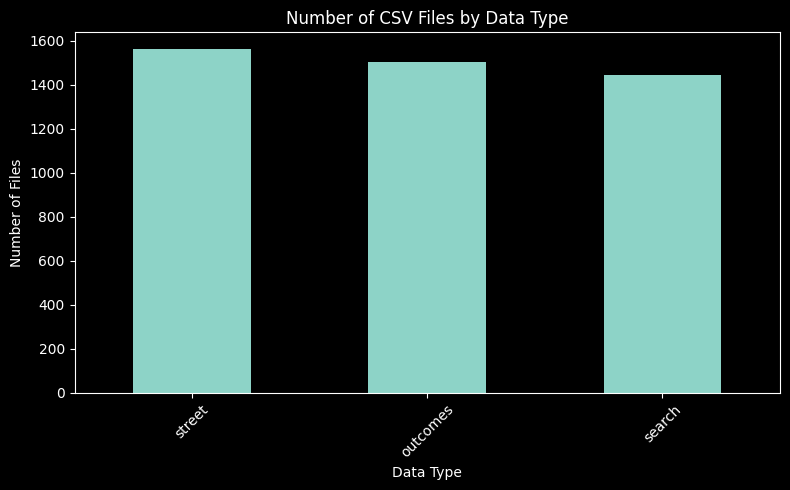

In [50]:
counts = inventory_df["data_type"].value_counts()

plt.figure(figsize=(8, 5))
counts.plot(kind="bar")
plt.title("Number of CSV Files by Data Type")
plt.xlabel("Data Type")
plt.ylabel("Number of Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

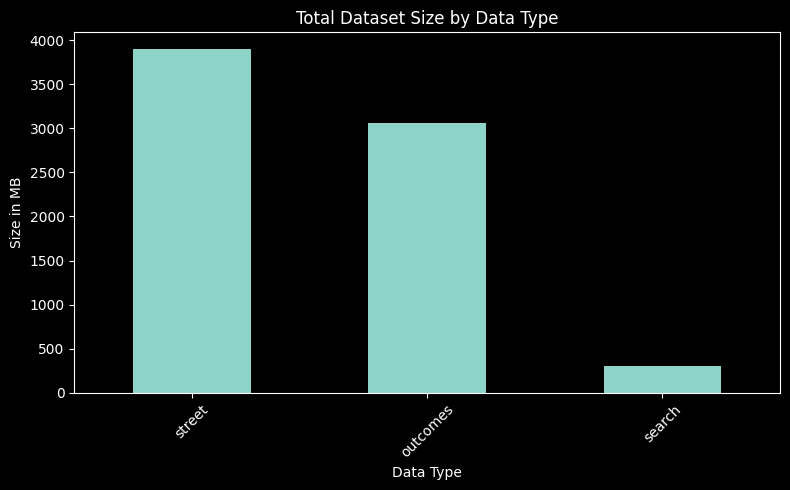

In [51]:
size_by_type = inventory_df.groupby("data_type")["file_size_mb"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
size_by_type.plot(kind="bar")
plt.title("Total Dataset Size by Data Type")
plt.xlabel("Data Type")
plt.ylabel("Size in MB")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

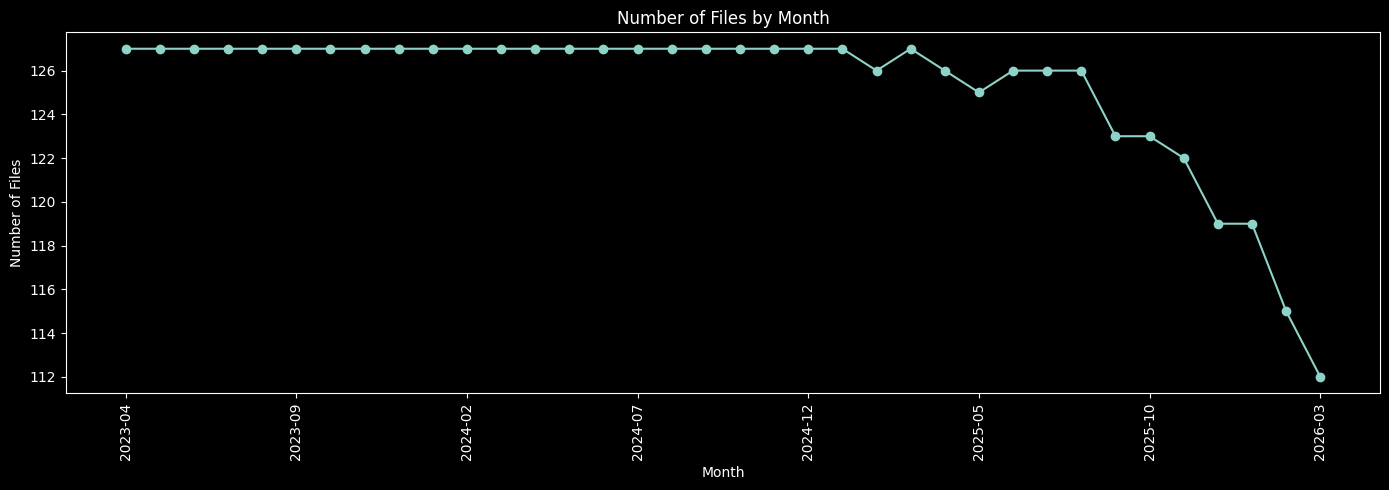

In [52]:
files_by_month = inventory_df["month"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
files_by_month.plot(kind="line", marker="o")
plt.title("Number of Files by Month")
plt.xlabel("Month")
plt.ylabel("Number of Files")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [53]:
column_records = []

for file in csv_files:
    try:
        sample = pd.read_csv(file, nrows=5, low_memory=False)
        column_records.append({
            "file_name": file.name,
            "file_path": str(file),
            "columns": tuple(sample.columns),
            "num_columns": len(sample.columns)
        })
    except Exception as e:
        column_records.append({
            "file_name": file.name,
            "file_path": str(file),
            "columns": None,
            "num_columns": None,
            "error": str(e)
        })

columns_df = pd.DataFrame(column_records)

columns_df.head()

,file_name,file_path,columns,num_columns
0,2023-04-avon-and-somerset-outcomes.csv,..\..\scripts\data\raw\extracted\2023-04\2023-...,"(Crime ID, Month, Reported by, Falls within, L...",10
1,2023-04-avon-and-somerset-stop-and-search.csv,..\..\scripts\data\raw\extracted\2023-04\2023-...,"(Type, Date, Part of a policing operation, Pol...",15
2,2023-04-avon-and-somerset-street.csv,..\..\scripts\data\raw\extracted\2023-04\2023-...,"(Crime ID, Month, Reported by, Falls within, L...",12
3,2023-04-bedfordshire-outcomes.csv,..\..\scripts\data\raw\extracted\2023-04\2023-...,"(Crime ID, Month, Reported by, Falls within, L...",10
4,2023-04-bedfordshire-stop-and-search.csv,..\..\scripts\data\raw\extracted\2023-04\2023-...,"(Type, Date, Part of a policing operation, Pol...",15


In [54]:
column_structure_counts = columns_df["columns"].value_counts()

print(f"Number of unique column structures: {len(column_structure_counts)}")

column_structure_counts

Number of unique column structures: 3


columns
(Crime ID, Month, Reported by, Falls within, Longitude, Latitude, Location, LSOA code, LSOA name, Crime type, Last outcome category, Context)                                                                                                                                      1561
(Crime ID, Month, Reported by, Falls within, Longitude, Latitude, Location, LSOA code, LSOA name, Outcome type)                                                                                                                                                                    1502
(Type, Date, Part of a policing operation, Policing operation, Latitude, Longitude, Gender, Age range, Self-defined ethnicity, Officer-defined ethnicity, Legislation, Object of search, Outcome, Outcome linked to object of search, Removal of more than just outer clothing)    1446
Name: count, dtype: int64

In [55]:
row_counts = []

for i, file in enumerate(csv_files, start=1):
    try:
        rows = sum(1 for _ in open(file, encoding="utf-8")) - 1
        row_counts.append({
            "file_name": file.name,
            "file_path": str(file),
            "rows": rows
        })
    except UnicodeDecodeError:
        rows = sum(1 for _ in open(file, encoding="latin1")) - 1
        row_counts.append({
            "file_name": file.name,
            "file_path": str(file),
            "rows": rows
        })
    except Exception as e:
        row_counts.append({
            "file_name": file.name,
            "file_path": str(file),
            "rows": None,
            "error": str(e)
        })
    
    if i % 250 == 0:
        print(f"Checked {i}/{len(csv_files)} files")

rows_df = pd.DataFrame(row_counts)

rows_df.head()

Checked 250/4509 files
Checked 500/4509 files
Checked 750/4509 files
Checked 1000/4509 files
Checked 1250/4509 files
Checked 1500/4509 files
Checked 1750/4509 files
Checked 2000/4509 files
Checked 2250/4509 files
Checked 2500/4509 files
Checked 2750/4509 files
Checked 3000/4509 files
Checked 3250/4509 files
Checked 3500/4509 files
Checked 3750/4509 files
Checked 4000/4509 files
Checked 4250/4509 files
Checked 4500/4509 files


,file_name,file_path,rows
0,2023-04-avon-and-somerset-outcomes.csv,..\..\scripts\data\raw\extracted\2023-04\2023-...,2749
1,2023-04-avon-and-somerset-stop-and-search.csv,..\..\scripts\data\raw\extracted\2023-04\2023-...,612
2,2023-04-avon-and-somerset-street.csv,..\..\scripts\data\raw\extracted\2023-04\2023-...,13733
3,2023-04-bedfordshire-outcomes.csv,..\..\scripts\data\raw\extracted\2023-04\2023-...,2408
4,2023-04-bedfordshire-stop-and-search.csv,..\..\scripts\data\raw\extracted\2023-04\2023-...,355


In [56]:
eda_df = inventory_df.merge(
    rows_df[["file_name", "rows"]],
    on="file_name",
    how="left"
)

eda_df.head()

,file_path,file_name,month,force,data_type,file_size_mb,rows
0,..\..\scripts\data\raw\extracted\2023-04\2023-...,2023-04-avon-and-somerset-outcomes.csv,2023-04,avon-and-somerset,outcomes,0.62,2749
1,..\..\scripts\data\raw\extracted\2023-04\2023-...,2023-04-avon-and-somerset-stop-and-search.csv,2023-04,avon-and-somerset-stop-and,search,0.13,612
2,..\..\scripts\data\raw\extracted\2023-04\2023-...,2023-04-avon-and-somerset-street.csv,2023-04,avon-and-somerset,street,3.13,13733
3,..\..\scripts\data\raw\extracted\2023-04\2023-...,2023-04-bedfordshire-outcomes.csv,2023-04,bedfordshire,outcomes,0.50,2408
4,..\..\scripts\data\raw\extracted\2023-04\2023-...,2023-04-bedfordshire-stop-and-search.csv,2023-04,bedfordshire-stop-and,search,0.08,355


In [57]:
total_rows = eda_df["rows"].sum()

print(f"Estimated total rows: {total_rows:,.0f}")

Estimated total rows: 33,641,800


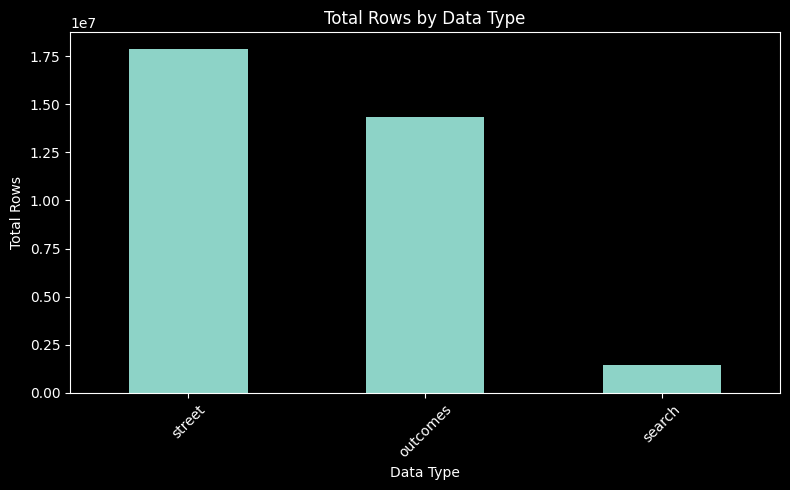

In [58]:
rows_by_type = eda_df.groupby("data_type")["rows"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
rows_by_type.plot(kind="bar")
plt.title("Total Rows by Data Type")
plt.xlabel("Data Type")
plt.ylabel("Total Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

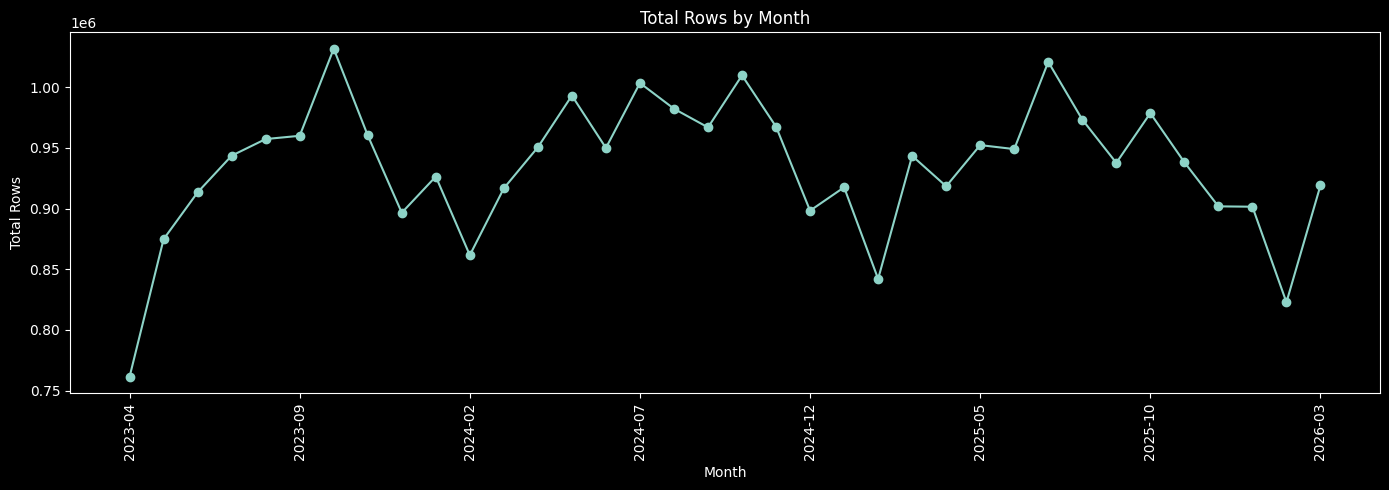

In [59]:
rows_by_month = eda_df.groupby("month")["rows"].sum().sort_index()

plt.figure(figsize=(14, 5))
rows_by_month.plot(kind="line", marker="o")
plt.title("Total Rows by Month")
plt.xlabel("Month")
plt.ylabel("Total Rows")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [60]:
sample_frames = []

for i, file in enumerate(csv_files, start=1):
    try:
        df_sample = pd.read_csv(file, nrows=1000, low_memory=False)
        df_sample["source_file"] = file.name
        sample_frames.append(df_sample)
    except Exception as e:
        print(f"Skipped {file.name}: {e}")
    
    if i % 250 == 0:
        print(f"Sampled {i}/{len(csv_files)} files")

sample_df = pd.concat(sample_frames, ignore_index=True, sort=False)

print(sample_df.shape)
sample_df.head()

Sampled 250/4509 files
Sampled 500/4509 files
Sampled 750/4509 files
Sampled 1000/4509 files
Sampled 1250/4509 files
Sampled 1500/4509 files
Sampled 1750/4509 files
Sampled 2000/4509 files
Sampled 2250/4509 files
Sampled 2500/4509 files
Sampled 2750/4509 files
Sampled 3000/4509 files
Sampled 3250/4509 files
Sampled 3500/4509 files
Sampled 3750/4509 files
Sampled 4000/4509 files
Sampled 4250/4509 files
Sampled 4500/4509 files
(3840261, 27)


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Outcome type,...,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome,Outcome linked to object of search,Removal of more than just outer clothing,Crime type,Last outcome category,Context
0,7232627bd610668b5cdf1f6bf32bb9e0dfb09d45b4e48e...,2023-04,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Unable to prosecute suspect,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ba0ef07f57ae84f9d2c1bb60ea71e09f70d79dc45425fc...,2023-04,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Unable to prosecute suspect,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,765e4c247bc9e33e40932e13e3d7621e5d579a5e4cfe17...,2023-04,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Formal action is not in the public interest,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f1ef106724ad7b9fed7a8252063655ff04ab279de32131...,2023-04,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Unable to prosecute suspect,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,35b955394a8cd4181b647adba7b3c488460e646f541133...,2023-04,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Formal action is not in the public interest,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


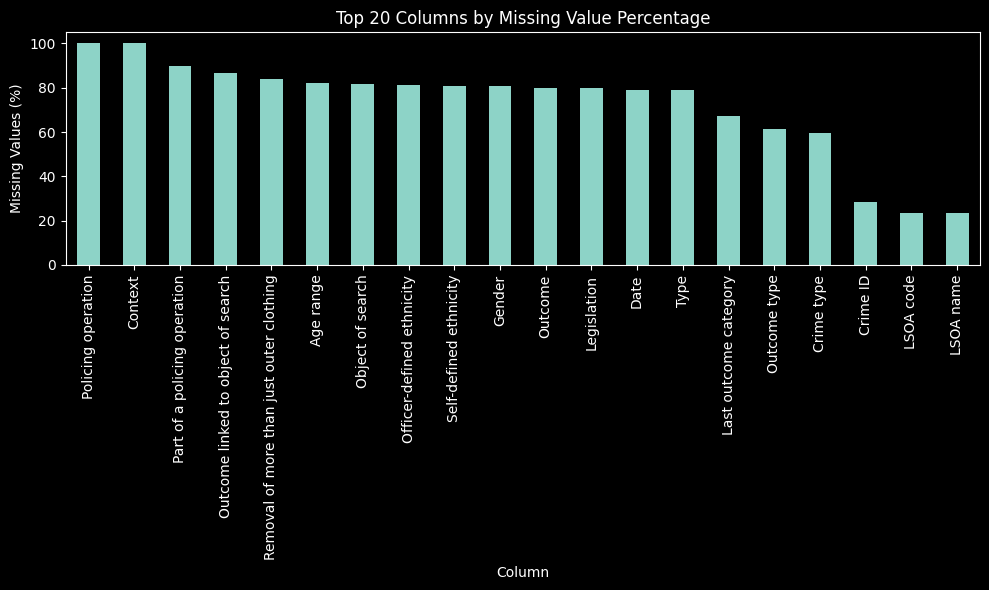

In [61]:
missing_percent = sample_df.isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
missing_percent.head(20).plot(kind="bar")
plt.title("Top 20 Columns by Missing Value Percentage")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [62]:
from collections import Counter
import pandas as pd

street_files = [file for file in csv_files if file.name.endswith("-street.csv")]

print(f"Number of street crime files found: {len(street_files)}")

crime_type_counter = Counter()
month_counter = Counter()
missing_counter = Counter()

total_rows = 0

columns_to_use = ["Month", "Crime type", "Longitude", "Latitude"]

for i, file in enumerate(street_files, start=1):
    try:
        for chunk in pd.read_csv(
            file,
            usecols=lambda col: col in columns_to_use,
            chunksize=100_000,
            low_memory=False
        ):
            rows = len(chunk)
            total_rows += rows

            crime_type_counter.update(chunk["Crime type"].dropna())
            month_counter.update(chunk["Month"].dropna())
            missing_counter.update(chunk.isna().sum().to_dict())

    except Exception as e:
        print(f"Skipped {file.name}: {e}")

    if i % 250 == 0:
        print(f"Processed {i}/{len(street_files)} street files")

print("Finished processing street crime files.")
print(f"Total street crime rows processed: {total_rows:,}")

Number of street crime files found: 1561
Processed 250/1561 street files
Processed 500/1561 street files
Processed 750/1561 street files
Processed 1000/1561 street files
Processed 1250/1561 street files
Processed 1500/1561 street files
Finished processing street crime files.
Total street crime rows processed: 17,849,542


In [63]:
crime_counts = (
    pd.DataFrame(crime_type_counter.items(), columns=["Crime type", "Count"])
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

month_counts = (
    pd.DataFrame(month_counter.items(), columns=["Month", "Count"])
    .sort_values("Month")
    .reset_index(drop=True)
)

missing_df = (
    pd.DataFrame(missing_counter.items(), columns=["Column", "Missing count"])
    .sort_values("Missing count", ascending=False)
    .reset_index(drop=True)
)

missing_df["Missing percentage"] = (missing_df["Missing count"] / total_rows) * 100

display(crime_counts.head(20))
display(month_counts.head())
display(missing_df)

,Crime type,Count
0,Violence and sexual offences,6180176
1,Anti-social behaviour,2864743
2,Shoplifting,1410346
3,Criminal damage and arson,1341228
4,Other theft,1270767
5,Public order,1248045
6,Vehicle crime,983004
7,Burglary,695483
8,Drugs,566402
9,Other crime,370871


,Month,Count
0,2023-04,511229
1,2023-05,535333
2,2023-06,544532
3,2023-07,533581
4,2023-08,520941


,Column,Missing count,Missing percentage
0,Longitude,263597,1.48
1,Latitude,263597,1.48
2,Month,0,0.00
3,Crime type,0,0.00


<Figure size 1200x600 with 0 Axes>

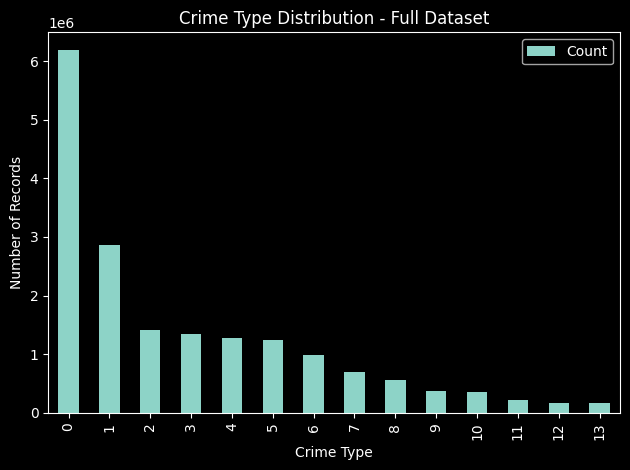

In [64]:
#crime_counts = street_df["Crime type"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
crime_counts.plot(kind="bar")
plt.title("Crime Type Distribution - Full Dataset")
plt.xlabel("Crime Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

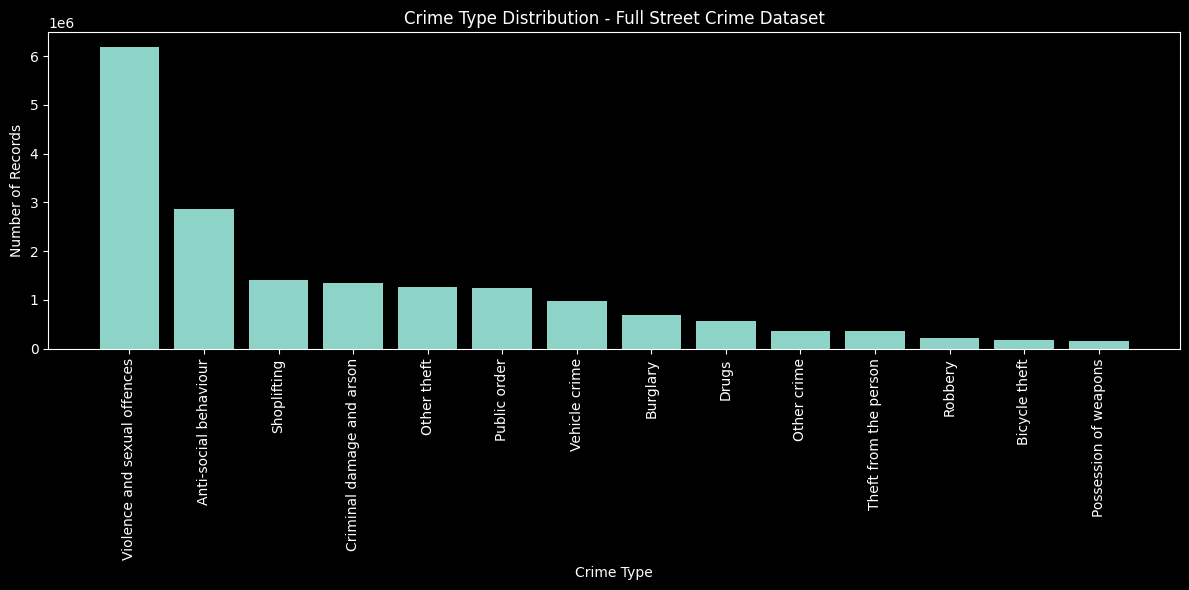

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(crime_counts["Crime type"], crime_counts["Count"])
plt.title("Crime Type Distribution - Full Street Crime Dataset")
plt.xlabel("Crime Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

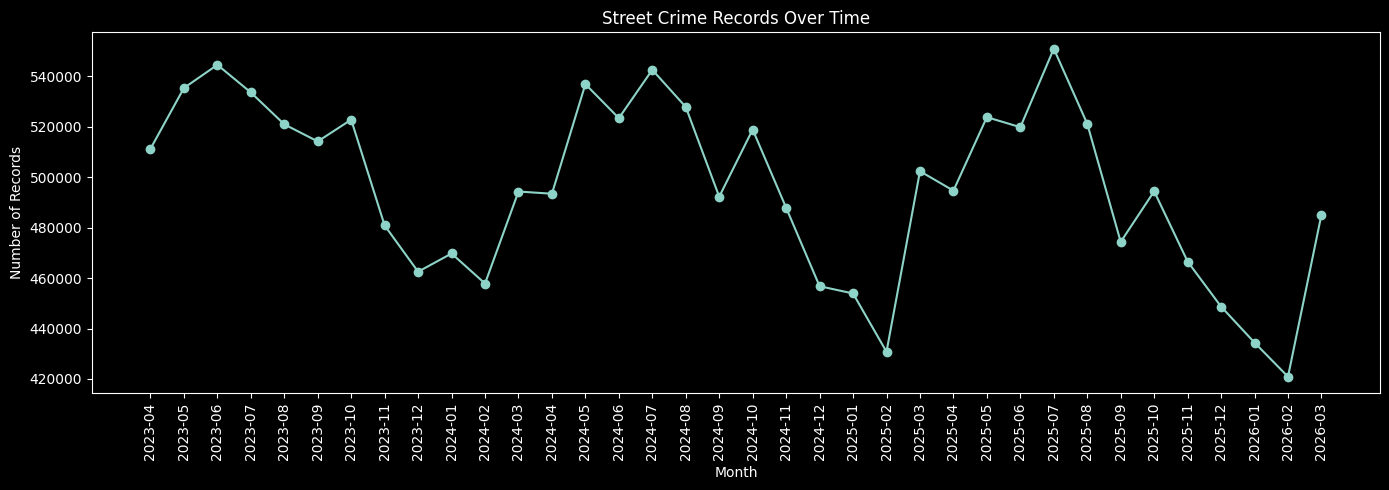

In [66]:
plt.figure(figsize=(14, 5))
plt.plot(month_counts["Month"], month_counts["Count"], marker="o")
plt.title("Street Crime Records Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

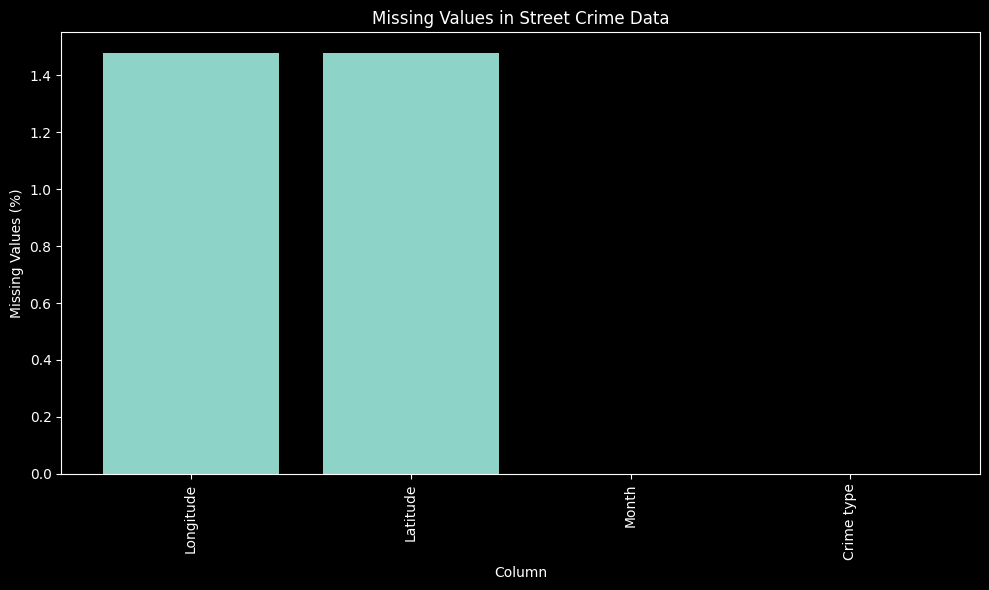

In [67]:
plt.figure(figsize=(10, 6))
plt.bar(missing_df["Column"], missing_df["Missing percentage"])
plt.title("Missing Values in Street Crime Data")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [68]:
pd.set_option('display.expand_frame_repr', False)

pd.set_option('display.precision', 2)

all_data = []

cols = ["Officer-defined ethnicity", "Gender", "Outcome","Age range","Object of search"]

stop_and_search_files = [file for file in csv_files if file.name.endswith("-stop-and-search.csv")]

for file in stop_and_search_files:
    try:
        df_chunk = pd.read_csv(file, usecols=cols)
        all_data.append(df_chunk)
    except Exception as e:
        print(f"Error in {file.name}: {e}")

df_total = pd.concat(all_data, ignore_index=True)

def add_stats(df):
    # Sum all outcome columns for the total
    outcome_cols = df.columns.difference(["Officer-defined ethnicity", "Gender","Age range","Object of search"])
    df['Total Interactions'] = df[outcome_cols].sum(axis=1)

    df['Arrest Rate (%)'] = (df['Arrest'] / df['Total Interactions']) * 100
    return df


table_ethnicity = (
    df_total.groupby("Officer-defined ethnicity")["Outcome"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
table_ethnicity = add_stats(table_ethnicity)

table_gendered = (
    df_total.groupby(["Officer-defined ethnicity", "Gender"])["Outcome"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
table_gendered = add_stats(table_gendered)

table_age= (
    df_total.groupby(["Officer-defined ethnicity", "Age range"])["Outcome"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
table_age = add_stats(table_age)

table_object_search = (
    df_total.groupby(["Object of search"])["Outcome"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
table_object_search = add_stats(table_object_search)


table_ethnicity.columns.name = None
table_gendered.columns.name = None
table_age.columns.name = None
table_object_search.columns.name = None

print("--- Table 1: Stats by Ethnicity ---")
print(table_ethnicity[['Officer-defined ethnicity', 'Total Interactions', 'Arrest', 'Arrest Rate (%)']])

print("\n--- Table 2: Stats by Ethnicity and Gender ---")
print(table_gendered[['Officer-defined ethnicity', 'Gender', 'Total Interactions', 'Arrest', 'Arrest Rate (%)']])


print("\n--- Table 3: Stats by Ethnicity and Age ---")
print(table_age[['Officer-defined ethnicity', 'Age range', 'Total Interactions', 'Arrest', 'Arrest Rate (%)']])


print("\n--- Table 4: Stats by Ethnicity and Object of Search ---")
print(table_object_search[['Object of search', 'Total Interactions', 'Arrest', 'Arrest Rate (%)']])


#total stop and searches - 1 281 167

--- Table 1: Stats by Ethnicity ---
  Officer-defined ethnicity  Total Interactions  Arrest  Arrest Rate (%)
0                     Asian              147162   20483            13.92
1                     Black              238966   40058            16.76
2                     Mixed                5096     965            18.94
3                     Other               43948    7249            16.49
4                     White              845995  127757            15.10

--- Table 2: Stats by Ethnicity and Gender ---
   Officer-defined ethnicity  Gender  Total Interactions  Arrest  Arrest Rate (%)
0                      Asian  Female                6432     604             9.39
1                      Asian    Male              130981   19022            14.52
2                      Asian   Other                5104     416             8.15
3                      Black  Female               15159    2133            14.07
4                      Black    Male              205086   36223    

In [69]:
from collections import Counter
import pandas as pd

target_forces = [
    "City of London Police",
    "Metropolitan Police Service",
    "West Midlands Police",
    "Merseyside Police",
    "West Yorkshire Police",
    "South Yorkshire Police",
    "Northumbria Police",
    "Leicestershire Police",
    "Nottinghamshire Police",
    "Humberside Police"
]

columns_to_use = ["Month", "Crime type", "Longitude", "Latitude", "Reported by"]
street_files = [file for file in csv_files if file.name.endswith("-street.csv")]

police_force_counter = Counter()
total_rows = 0

for i, file in enumerate(street_files, start=1):
    try:
        for chunk in pd.read_csv(
            file,
            usecols=lambda col: col in columns_to_use,
            chunksize=100_000,
            low_memory=False
        ):

            filtered_chunk = chunk[chunk["Reported by"].isin(target_forces)]

            total_rows += len(filtered_chunk)
            police_force_counter.update(filtered_chunk["Reported by"].dropna())

    except Exception as e:
        print(f"Skipped {file.name}: {e}")

    if i % 250 == 0:
        print(f"Processed {i}/{len(street_files)} street files")

df_ranked = pd.DataFrame(
    police_force_counter.most_common(),
    columns=["Police Force", "Rows"]
)

city_map = {
    "City of London Police": "London (The 'Square Mile' financial district)",
    "Metropolitan Police Service": "London (Greater London)",
    "West Midlands Police": "Birmingham",
    "Merseyside Police": "Liverpool",
    "West Yorkshire Police": "Leeds",
    "South Yorkshire Police": "Sheffield",
    "Northumbria Police": "Newcastle upon Tyne",
    "Leicestershire Police": "Leicester",
    "Nottinghamshire Police": "Nottingham",
    "Humberside Police": "Hull"
}

df_ranked["Primary City / Hub"] = df_ranked["Police Force"].map(city_map)
df_ranked.insert(0, 'Rank', range(1, len(df_ranked) + 1))

print("Final Filtered Ranking:")
print(df_ranked[["Rank", "Police Force", "Primary City / Hub", "Rows"]])

Processed 250/1561 street files
Processed 500/1561 street files
Processed 750/1561 street files
Processed 1000/1561 street files
Processed 1250/1561 street files
Processed 1500/1561 street files
Final Filtered Ranking:
   Rank                 Police Force                             Primary City / Hub     Rows
0     1  Metropolitan Police Service                        London (Greater London)  3415820
1     2         West Midlands Police                                     Birmingham  1011509
2     3        West Yorkshire Police                                          Leeds   926624
3     4       South Yorkshire Police                                      Sheffield   529538
4     5           Northumbria Police                            Newcastle upon Tyne   520784
5     6            Merseyside Police                                      Liverpool   463933
6     7       Nottinghamshire Police                                     Nottingham   377311
7     8        Leicestershire Police 

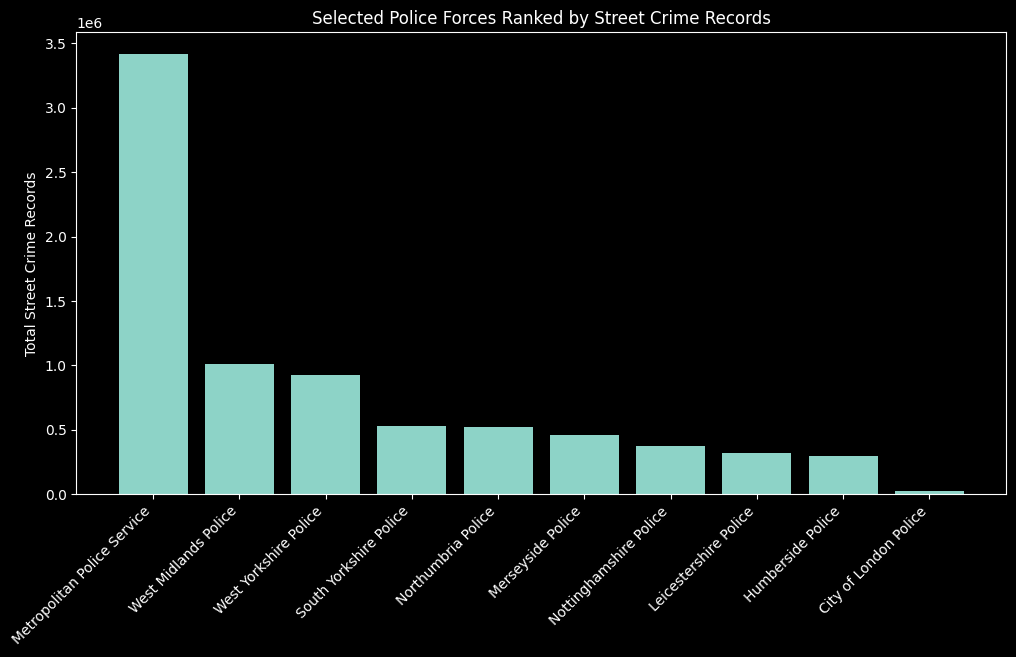

In [70]:
import matplotlib.pyplot as plt

top_10 = df_ranked.head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10["Police Force"], top_10["Rows"])
plt.xticks(rotation=45, ha='right')
plt.title("Selected Police Forces Ranked by Street Crime Records")
plt.ylabel("Total Street Crime Records")
plt.show()

In [71]:
import pandas as pd

target_forces = [
    "City of London Police", "Metropolitan Police Service", "West Midlands Police",
    "Merseyside Police", "West Yorkshire Police", "South Yorkshire Police",
    "Northumbria Police", "Leicestershire Police", "Nottinghamshire Police", "Humberside Police"
]

target_crimes = [
    "Violence and sexual offences", "Shoplifting", "Drugs",
    "Possession of weapons", "Robbery"
]

city_map = {
    "City of London Police": "London ('Square Mile' financial district)",
    "Metropolitan Police Service": "London (Greater London)",
    "West Midlands Police": "Birmingham", "Merseyside Police": "Liverpool",
    "West Yorkshire Police": "Leeds", "South Yorkshire Police": "Sheffield",
    "Northumbria Police": "Newcastle upon Tyne", "Leicestershire Police": "Leicester",
    "Nottinghamshire Police": "Nottingham", "Humberside Police": "Hull"
}

# 2. Processing Loop
results = []

for file in street_files:
    try:
        for chunk in pd.read_csv(file, usecols=["Reported by", "Crime type"], chunksize=100_000):

            mask = (chunk["Reported by"].isin(target_forces)) & (chunk["Crime type"].isin(target_crimes))
            filtered = chunk[mask]

            if not filtered.empty:

                counts = filtered.groupby(["Reported by", "Crime type"]).size().reset_index(name="count")
                results.append(counts)
    except Exception as e:
        print(f"Error in {file.name}: {e}")


df_total = pd.concat(results).groupby(["Reported by", "Crime type"])["count"].sum().reset_index()

pivot_df = df_total.pivot(index="Reported by", columns="Crime type", values="count").fillna(0).astype(int)


pivot_df["Selected crime total"] = pivot_df.sum(axis=1)

# Reset index to bring "Reported by" back as a column and add City Hubs
pivot_df = pivot_df.reset_index()
pivot_df["Primary City / Hub"] = pivot_df["Reported by"].map(city_map)

pivot_df = pivot_df.sort_values("Selected crime total", ascending=False).reset_index(drop=True)
pivot_df.insert(0, 'Rank', range(1, len(pivot_df) + 1))

cols = ["Rank", "Reported by", "Primary City / Hub"] + target_crimes + ["Selected crime total"]
pivot_df = pivot_df[cols]

crime_totals = df_total.groupby("Crime type")["count"].sum().sort_values(ascending=False).reset_index()

crime_totals

,Crime type,count
0,Violence and sexual offences,2472384
1,Shoplifting,609847
2,Drugs,279735
3,Robbery,153156
4,Possession of weapons,68086


In [72]:
pivot_df

Crime type,Rank,Reported by,Primary City / Hub,Violence and sexual offences,Shoplifting,Drugs,Possession of weapons,Robbery,Selected crime total
0,1,Metropolitan Police Service,London (Greater London),795167,235470,130957,15584,96779,1273957
1,2,West Midlands Police,Birmingham,407308,88836,25224,19603,21948,562919
2,3,West Yorkshire Police,Leeds,381823,65461,29434,7693,10379,494790
3,4,Merseyside Police,Liverpool,182858,28181,37477,3990,3761,256267
4,5,South Yorkshire Police,Sheffield,177890,43380,16209,6366,6143,249988
5,6,Northumbria Police,Newcastle upon Tyne,166607,50281,12049,4469,4366,237772
6,7,Nottinghamshire Police,Nottingham,115768,44668,11902,4954,3988,181280
7,8,Humberside Police,Hull,122580,25890,5437,2432,2561,158900
8,9,Leicestershire Police,Leicester,117453,23497,9444,2780,2624,155798
9,10,City of London Police,London ('Square Mile' financial district),4930,4183,1602,215,607,11537


NOW PLOT

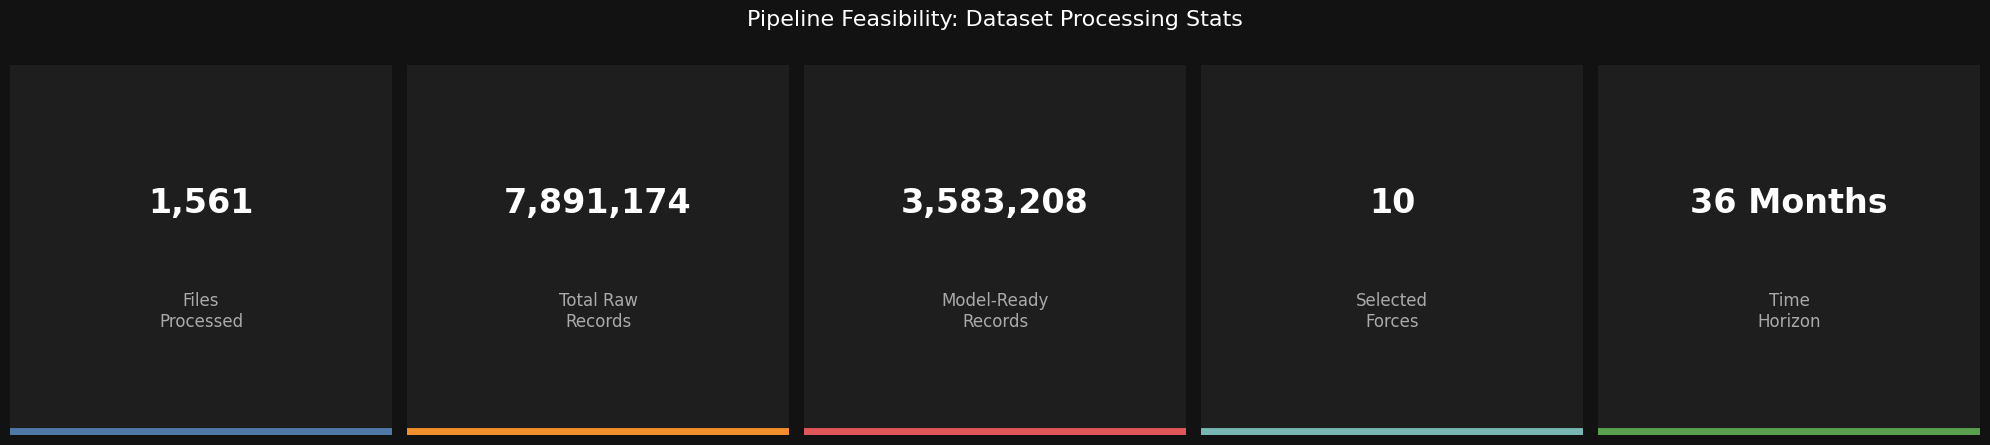

In [73]:

total_files = len(street_files)
total_raw_rows = total_rows
filtered_rows = pivot_df["Selected crime total"].sum()
unique_forces = pivot_df["Reported by"].nunique()
unique_crimes = len(target_crimes)

date_range = f"{min(month_counter.keys())} to {max(month_counter.keys())}"


def plot_stat_cards(metrics):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.patch.set_facecolor('#121212')

    colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']

    for i, (label, value) in enumerate(metrics.items()):
        ax = axes[i]
        ax.set_facecolor('#1e1e1e')
        ax.text(0.5, 0.6, str(value), fontsize=24, fontweight='bold', color='white', ha='center')
        ax.text(0.5, 0.3, label, fontsize=12, color='#aaaaaa', ha='center', wrap=True)

        ax.axhline(y=0, color=colors[i], linewidth=10)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    plt.suptitle("Pipeline Feasibility: Dataset Processing Stats", color='white', fontsize=16, y=1.1)
    plt.show()

metrics_data = {
    "Files\nProcessed": f"{total_files:,}",
    "Total Raw\nRecords": f"{total_raw_rows:,}",
    "Model-Ready\nRecords": f"{filtered_rows:,}",
    "Selected\nForces": unique_forces,
    "Time\nHorizon": "36 Months"
}

plot_stat_cards(metrics_data)

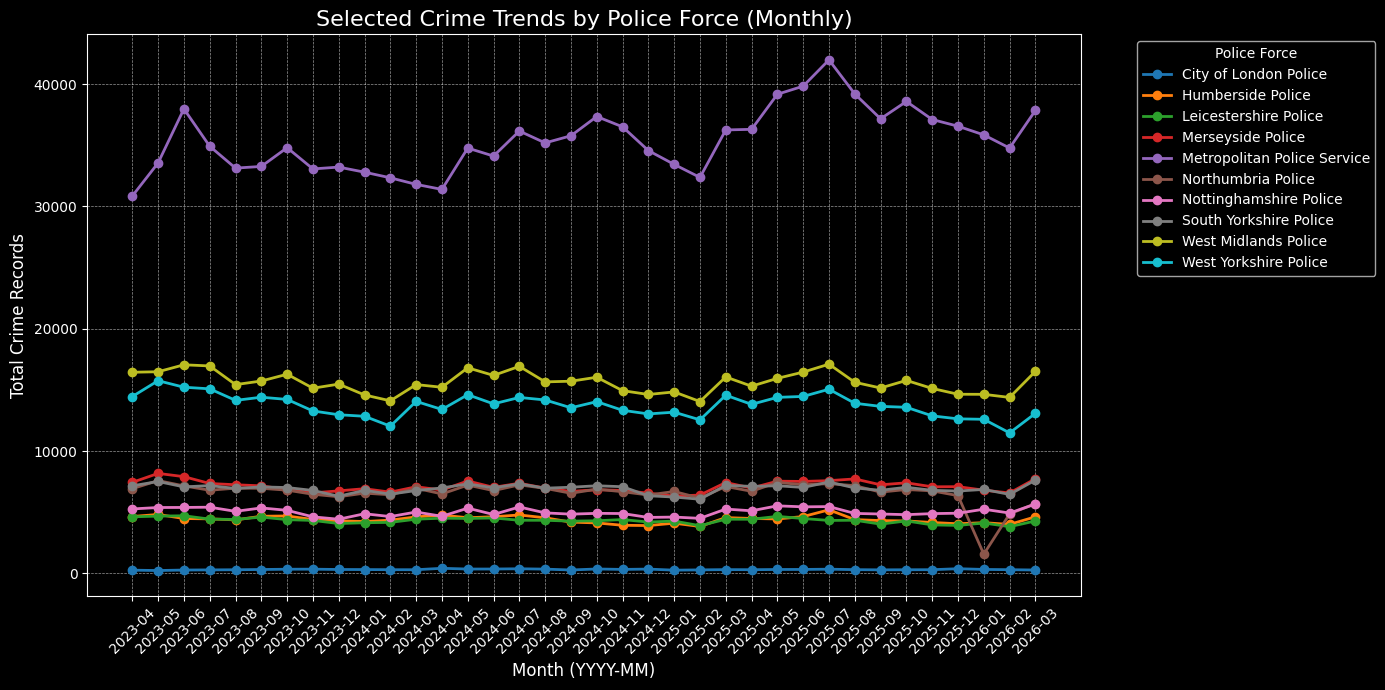

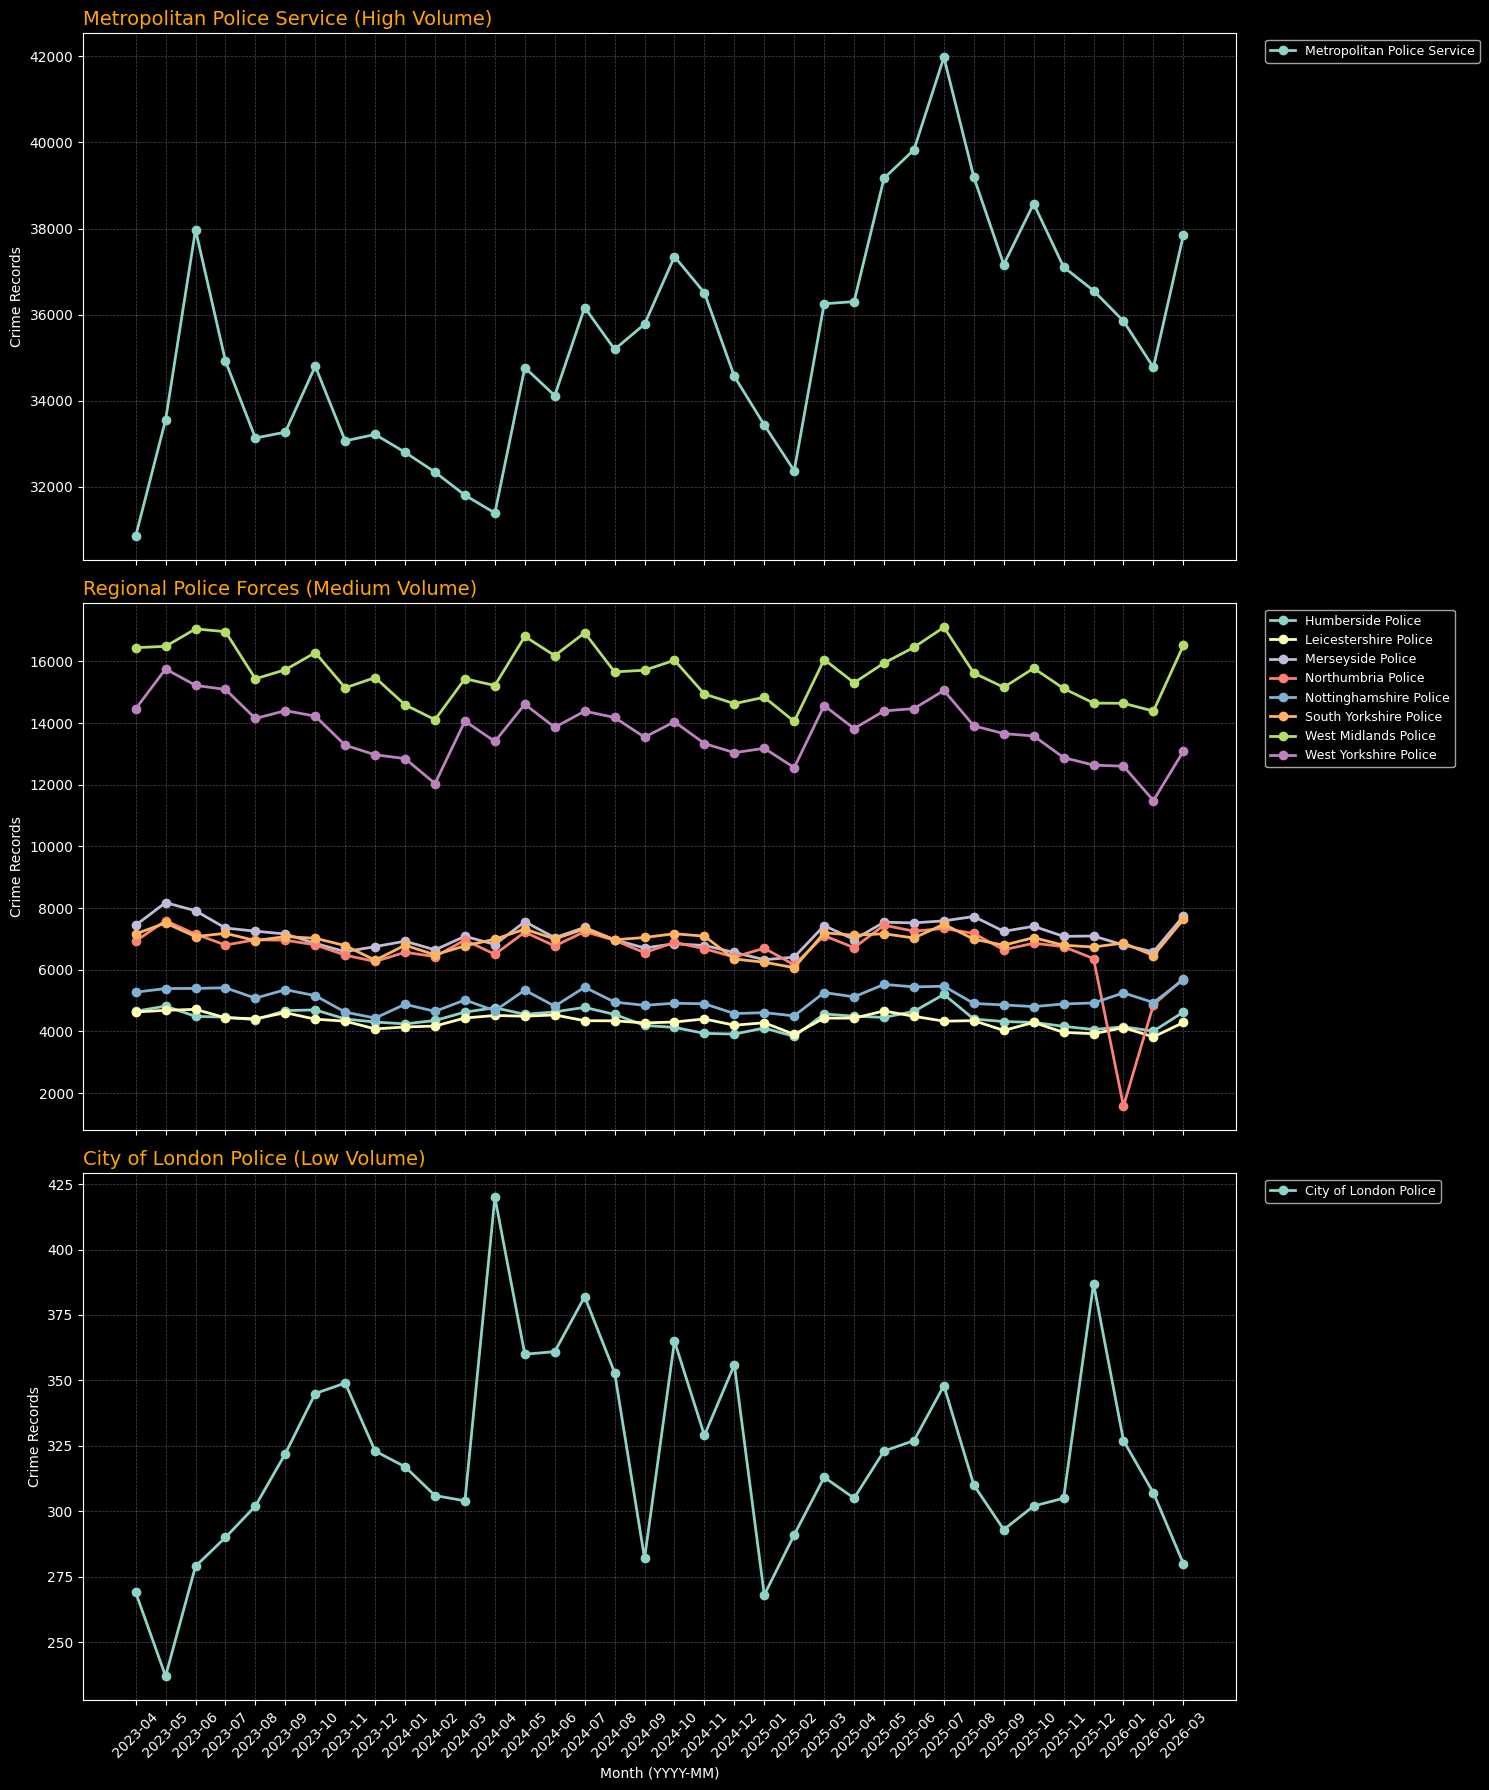

In [74]:
trend_results = []

for file in street_files:
    try:
        for chunk in pd.read_csv(file, usecols=["Month", "Reported by", "Crime type"], chunksize=100_000):
            mask = (chunk["Reported by"].isin(target_forces)) & (chunk["Crime type"].isin(target_crimes))
            filtered = chunk[mask]

            if not filtered.empty:

                counts = filtered.groupby(["Month", "Reported by"]).size().reset_index(name="count")
                trend_results.append(counts)
    except Exception as e:
        print(f"Error: {e}")

df_trend = pd.concat(trend_results).groupby(["Month", "Reported by"])["count"].sum().reset_index()
df_trend = df_trend.sort_values("Month")

pivot_trend = df_trend.pivot(index="Month", columns="Reported by", values="count").fillna(0)
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

colors = plt.cm.    tab10.colors

for i, force in enumerate(pivot_trend.columns):
    plt.plot(pivot_trend.index, pivot_trend[force],
             marker='o', label=force, linewidth=2, color=colors[i % 10])

plt.title("Selected Crime Trends by Police Force (Monthly)", fontsize=16)
plt.xlabel("Month (YYYY-MM)", fontsize=12)
plt.ylabel("Total Crime Records", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Police Force", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

met_force = ["Metropolitan Police Service"]
city_force = ["City of London Police"]
other_forces = [f for f in pivot_trend.columns if f not in met_force + city_force]

fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)
plt.style.use('dark_background')

groups = [
    (met_force, "Metropolitan Police Service (High Volume)", axes[0]),
    (other_forces, "Regional Police Forces (Medium Volume)", axes[1]),
    (city_force, "City of London Police (Low Volume)", axes[2])
]

for forces, title, ax in groups:
    for force in forces:
        ax.plot(pivot_trend.index, pivot_trend[force], marker='o', label=force, linewidth=2)

    ax.set_title(title, fontsize=14, color='orange', loc='left')
    ax.set_ylabel("Crime Records")
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.xticks(rotation=45)
plt.xlabel("Month (YYYY-MM)")
plt.tight_layout()
plt.show()

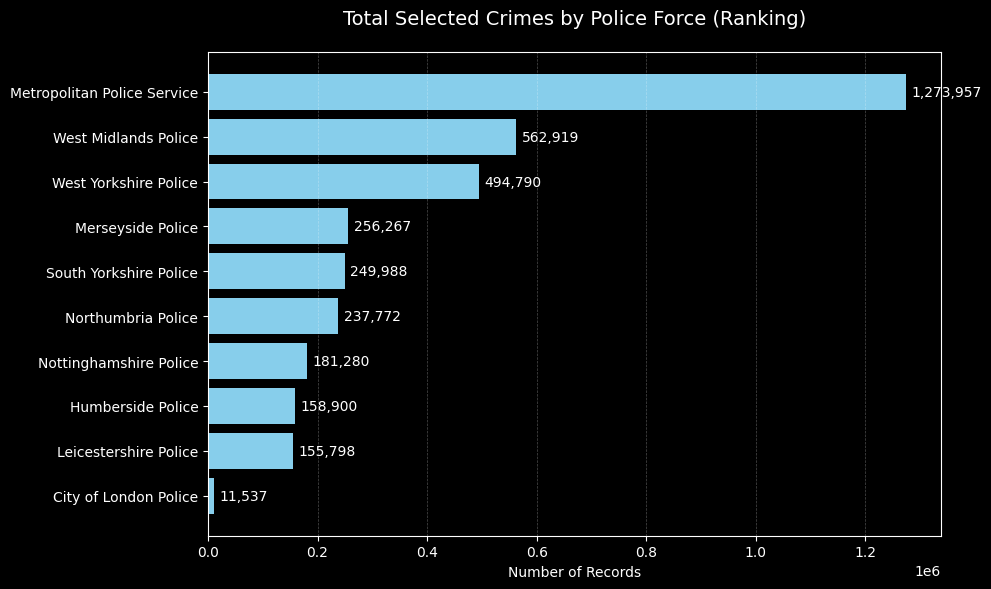

C:\Users\gtson\AppData\Local\Temp\ipykernel_15012\3180838313.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crime_totals_sorted, x="count", y="Crime type", palette="magma")


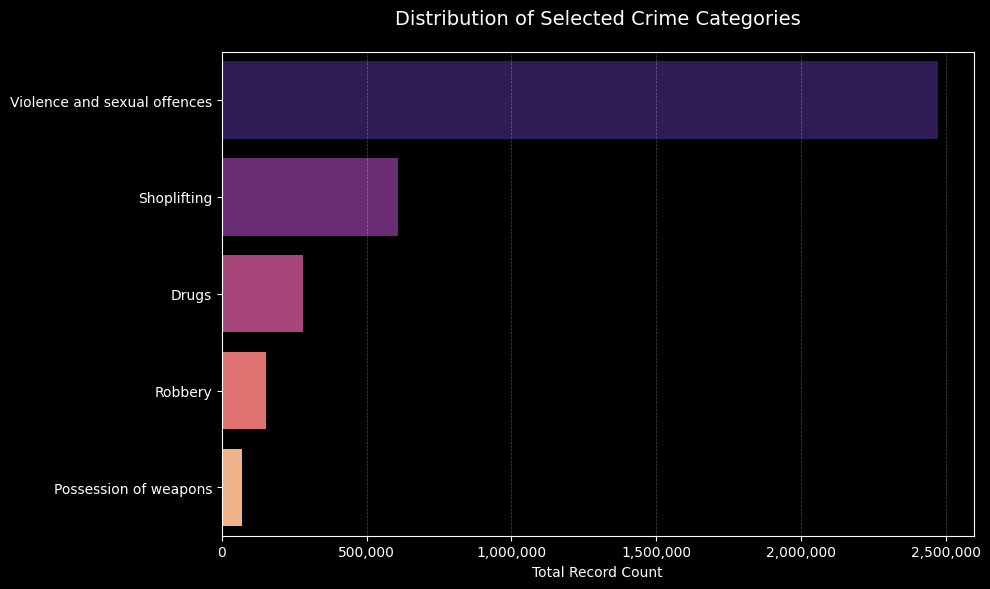

In [75]:
plot_df_3 = pivot_df.sort_values("Selected crime total", ascending=True)

plt.figure(figsize=(10, 6))
plt.style.use('dark_background')

bars = plt.barh(plot_df_3["Reported by"], plot_df_3["Selected crime total"], color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10000, bar.get_y() + bar.get_height()/2,
             f'{width:,}', va='center', color='white', fontsize=10)

plt.title("Total Selected Crimes by Police Force (Ranking)", fontsize=14, pad=20)
plt.xlabel("Number of Records")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

crime_totals_sorted = crime_totals.sort_values("count", ascending=False)

sns.barplot(data=crime_totals_sorted, x="count", y="Crime type", palette="magma")

plt.title("Distribution of Selected Crime Categories", fontsize=14, pad=20)
plt.xlabel("Total Record Count")
plt.ylabel("") # Hide ylabel as it's redundant
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

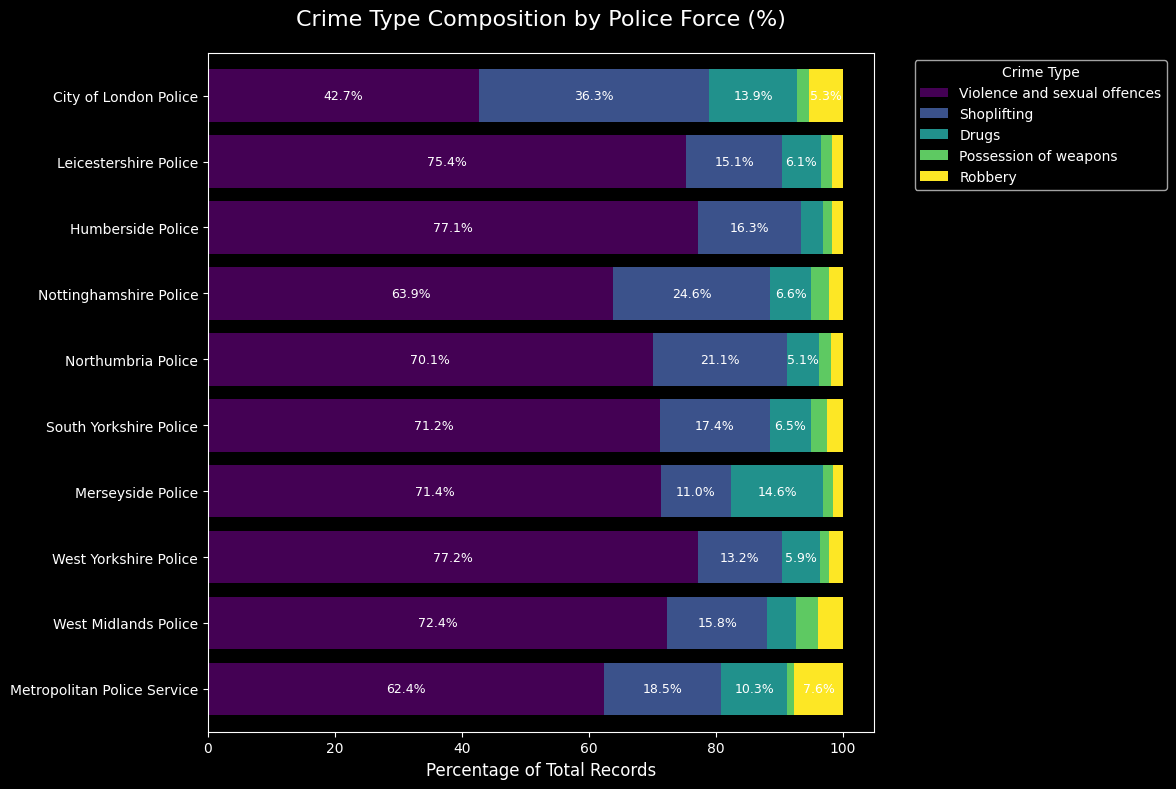

In [76]:
crime_cols = ["Violence and sexual offences", "Shoplifting", "Drugs", "Possession of weapons", "Robbery"]

pct_df = pivot_df.set_index("Reported by")[crime_cols]
pct_df = pct_df.div(pct_df.sum(axis=1), axis=0) * 100

plt.style.use('dark_background')
ax = pct_df.plot(kind='barh',
                 stacked=True,
                 figsize=(12, 8),
                 width=0.8,
                 colormap='viridis')


plt.title("Crime Type Composition by Police Force (%)", fontsize=16, pad=20)
plt.xlabel("Percentage of Total Records", fontsize=12)
plt.ylabel("")
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width = p.get_width()
    if width > 5:
        x, y = p.get_xy()
        ax.annotate(f'{width:.1f}%',
                    (x + width/2, y + p.get_height()/2),
                    ha='center', va='center', fontsize=9, color='white')

plt.tight_layout()
plt.show()

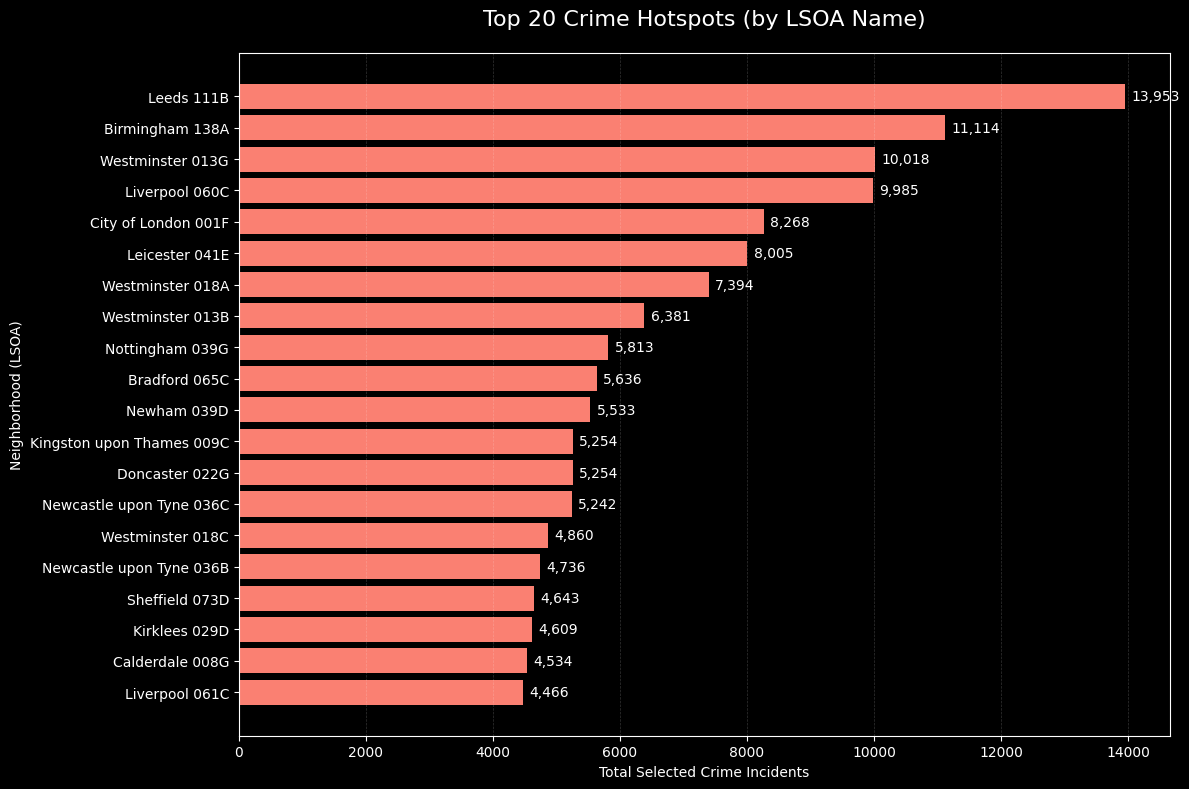

In [77]:
lsoa_counter = Counter()

for file in street_files:
    try:
        for chunk in pd.read_csv(file, usecols=["Reported by", "Crime type", "LSOA name"], chunksize=100_000):
            mask = (chunk["Reported by"].isin(target_forces)) & (chunk["Crime type"].isin(target_crimes))
            filtered = chunk[mask]

            if not filtered.empty:
                lsoa_counter.update(filtered["LSOA name"].dropna())
    except Exception as e:
        continue


top_lsoas = pd.DataFrame(lsoa_counter.most_common(20), columns=["LSOA Name", "Crime Count"])


plt.figure(figsize=(12, 8))
plt.style.use('dark_background')

bars = plt.barh(top_lsoas["LSOA Name"], top_lsoas["Crime Count"], color='salmon')

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', color='white')

plt.title("Top 20 Crime Hotspots (by LSOA Name)", fontsize=16, pad=20)
plt.xlabel("Total Selected Crime Incidents")
plt.ylabel("Neighborhood (LSOA)")
plt.grid(axis='x', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

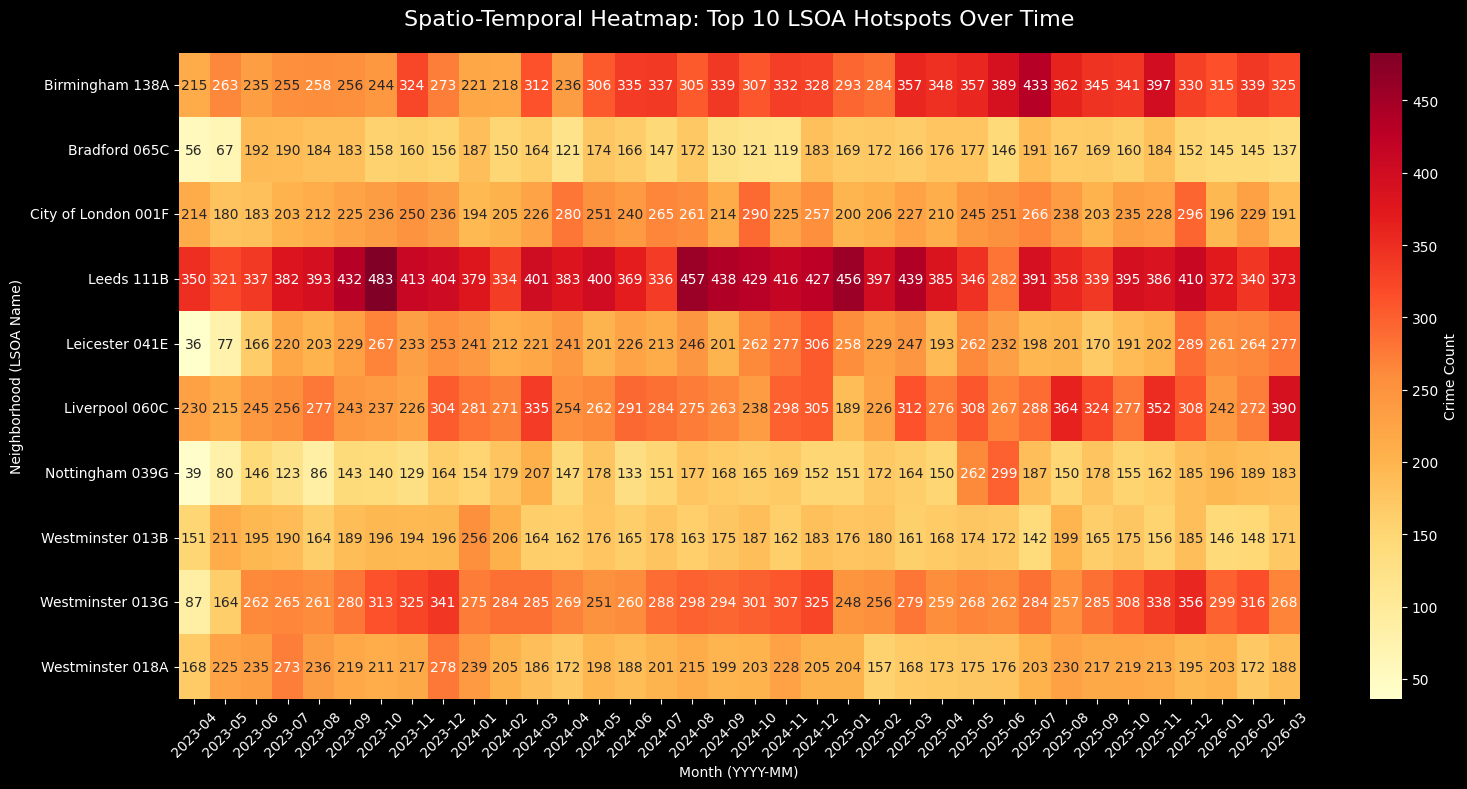

In [78]:
top_10_lsoa_names = [name for name, count in lsoa_counter.most_common(10)]

heatmap_results = []

for file in street_files:
    try:
        for chunk in pd.read_csv(file, usecols=["Month", "LSOA name", "Crime type", "Reported by"], chunksize=100_000):
            # Filter for Target Forces, Target Crimes, AND our Top 10 LSOAs
            mask = (chunk["Reported by"].isin(target_forces)) & \
                   (chunk["Crime type"].isin(target_crimes)) & \
                   (chunk["LSOA name"].isin(top_10_lsoa_names))
            filtered = chunk[mask]

            if not filtered.empty:
                counts = filtered.groupby(["Month", "LSOA name"]).size().reset_index(name="count")
                heatmap_results.append(counts)
    except:
        continue


df_heatmap = pd.concat(heatmap_results).groupby(["Month", "LSOA name"])["count"].sum().reset_index()
pivot_heatmap = df_heatmap.pivot(index="LSOA name", columns="Month", values="count").fillna(0)


plt.figure(figsize=(16, 8))
sns.heatmap(pivot_heatmap, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={'label': 'Crime Count'})

plt.title("Spatio-Temporal Heatmap: Top 10 LSOA Hotspots Over Time", fontsize=16, pad=20)
plt.xlabel("Month (YYYY-MM)")
plt.ylabel("Neighborhood (LSOA Name)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

DELETE THIS

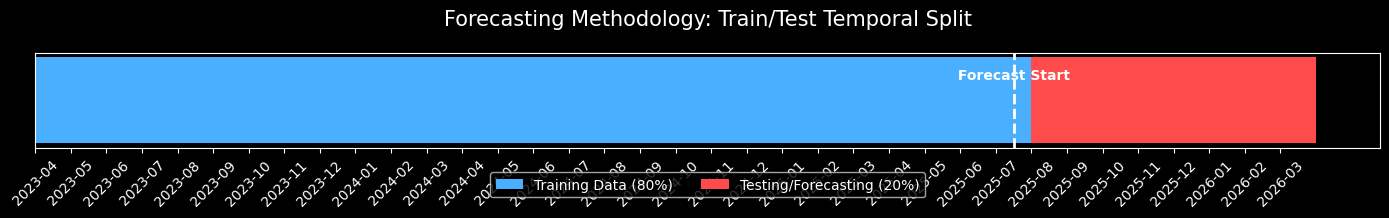

Training Period: 2023-04 to 2025-07
Testing Period:  2025-08 to 2026-03


In [79]:

all_months = sorted(df_heatmap['Month'].unique())
split_index = int(len(all_months) * 0.8)

train_months = all_months[:split_index]
test_months = all_months[split_index:]

plt.figure(figsize=(14, 3))
plt.style.use('dark_background')

plt.barh("Timeline", len(train_months), left=0, color='#4bafff', label='Training Data (80%)')

plt.barh("Timeline", len(test_months), left=len(train_months), color='#ff4b4b', label='Testing/Forecasting (20%)')

plt.xticks(range(len(all_months)), all_months, rotation=45)

plt.axvline(x=split_index - 0.5, color='white', linestyle='--', linewidth=2)
plt.text(split_index - 0.5, 0.2, ' Forecast Start ', color='white', ha='center', fontweight='bold')

plt.title("Forecasting Methodology: Train/Test Temporal Split", fontsize=15, pad=20)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.6), ncol=2)
plt.yticks([])
plt.tight_layout()
plt.show()

print(f"Training Period: {train_months[0]} to {train_months[-1]}")
print(f"Testing Period:  {test_months[0]} to {test_months[-1]}")